In [1]:
import os
import gc
import sys
import json
import pickle
import Grammar
import textacy
import functools
import pandas as pd
import spacy
import ahocorasick
from pathlib import Path
from spacy.tokens import Span
from taxonerd import TaxoNERD
import Entity
from tqdm.auto import tqdm
from typing import List, Any
import cProfile, pstats, io
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from typing import Dict, Set

Loading Mapped Names...
# of Mapped Names: 404008

Loading Vernaculars...
# of Vernacular Names: 377714

Loading Scientfics...
# of Scientific Groups: 17

Loading Roles...
# of Roles: 14

Loading Interactions...
# of Interactions: 25

Loading Actions...
# of Actions: 319

Loading All Names...
# of Names: 8836313



C:\Users\lbeln\anaconda3\envs\3.10_CUDA\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel("../papers/benchmarks/Benchmark-03-09.xlsx")
df = df[(df['Score'] == 0) | (df['Score'] == 1) | (df['Score'] == 3)]
df.reset_index(inplace=True)
texts = df.Abstract.tolist()
number_texts = len(texts)

In [3]:
# True Papers
df_T = df[df['Score'] == 3]
texts_T = df_T.Abstract.tolist()
number_texts_T = len(texts_T)

In [4]:
# False Papers
df_F = df[(df['Score'] < 3) & (df['Score'] >= 0)]
texts_F = df_F.Abstract.tolist()
number_texts_F = len(texts_F)

In [5]:
def satisfies_ent_req(doc: Entity.ExtendedDoc, ent_instances: List[Span], ents: List[Entity.Entity], verbose=False) -> bool:
    if verbose:
        print('Ents')
        for ent in ent_instances:
            print(ent)
        print()
        print()
    
    # Calculate Counts of Groups
    counts = {}
    for ent in ent_instances:
        ent_text = doc.text_lower[ent.start_char:ent.end_char]
        counts[ent_text] = counts.get(ent_text, 0) + 1
    
    if verbose:
        print('Counts')
        for k, v in counts.items():
            print(v, k)
        print()
        print()
    
    if verbose:
        print('Group\'s Lowers')
        for ent in ents:
            print(ent['lowers'])
        print()
        print()

    # Calculate Counts for Lowers
    lowers: Any = {}
    for ent in ents:
        for lower in ent['lowers']:
            lowers[lower] = lowers.get(lower, 0) +  1

    if verbose:
        print('Lowers')
        for k, v in lowers.items():
            print(v, k)
        print()
        print()

    # Calculate Counts for Entities
    for ent in ents:
        ent['count'] = sum([counts[lower] for lower in ent['lowers']]) # type: ignore
        if verbose:
            print(ent['lowers'], ent['count']) # type: ignore
    if verbose:
        print()
        print()

    non_role_labels = {'v', 's', 'm'}
    non_role_ents = list(ent for ent in ents if non_role_labels & ent['labels'])

    cond_length = len(non_role_ents) >= 2 # Must have >= 2 groups
    cond_counts = len([group for group in non_role_ents if group['count'] >= 2]) >= 2 #type: ignore # Must have at least 2 groups with >= 2 mentions

    flag = cond_length and cond_counts
    
    return flag

In [6]:
def satisfies_int_req(doc: Entity.ExtendedDoc, ent_instances: List[Span], ents: List[Entity.Entity], verbose=False) -> bool:
    mapped_ents = {}
    for j, ent in enumerate(ents):
        if verbose:
            print('Spans', ent['spans'])
        for span in ent['spans']:
            for token in span:
                if token.i not in mapped_ents:
                    mapped_ents[token.i] = set()
                mapped_ents[token.i].add(j)
        if verbose:
            print()
            print()
    
    if verbose:
        print('Mapped Entities:')
        print(mapped_ents)

    # ------------------------- #
    # METHOD 1: 
    # Look for Species in Triples
    # ------------------------- #
    triples = list(textacy.extract.subject_verb_object_triples(doc.doc)) # type: ignore
    for triple in triples:
        if verbose:
            print('Initial Triple: ', triple)
        
        # This could be done in two lines,
        # but I want to include verbose 
        # statements.
        ents_in_sub = set()
        for subject in triple.subject:
            span = Entity.expand_unit(doc.doc, subject.i, subject.i, max(0, subject.i - 7), min(len(doc.doc) - 1, subject.i + 7), speech = ['NOUN', 'PROPN', 'ADJ', 'DET', 'ADP', 'NUM'], literals=[], include=True, direction='BOTH')
            if verbose:
                print('Subject', subject, type(subject), subject.i, doc.doc[subject.i])
                print('Span-Subject', span, type(subject), subject.i)
            
            if not span:
                continue
            for token in span:
                if verbose:
                    print('\tToken in Span', token, token.i)
                if token.i in mapped_ents:
                    ents_in_sub.update(mapped_ents[token.i])

        ents_in_obj = set()
        for object in triple.object:    
            span = Entity.expand_unit(doc.doc, object.i, object.i, max(0, object.i - 7), min(len(doc.doc) - 1, object.i + 7), speech = ['NOUN', 'PROPN', 'ADJ', 'DET', 'ADP', 'NUM'], literals=[], include=True, direction='BOTH')
            if not span:
                continue
            
            if verbose:
                print('Object', object, type(object), object.i, doc.doc[object.i])
                print('Span Object', span, type(object), object.i)
            
            for token in span:
                if verbose:
                    print('\tToken in Span', token, token.i)
                if token.i in mapped_ents:
                    ents_in_obj.update(mapped_ents[token.i])

        
        if verbose:
            print('\tEntities of S:', ents_in_sub)
            print('\tEntities of O:', ents_in_obj)


        if ents_in_sub and ents_in_obj and ents_in_sub ^ ents_in_obj:
            return True
    
    # ---------------------------------------------------------- #
    # METHOD 2: 
    # Look for Interaction + Cause-Change (Action) + 1-2 Species
    # ---------------------------------------------------------- #

    # Interaction Tokens
    interaction_tokens = set()
    for r_i, key in Entity.interactions.iter(doc.text_lower):
        r_i += 1
        l_i = r_i - len(key)

        if verbose:
            print('\tInteraction Key Found: ', key)
        
        if (
            (l_i != 0 and not Entity.is_boundary(doc.text_lower[l_i-1])) or 
            (r_i != len(doc.text_lower) and not Entity.is_boundary(doc.text_lower[r_i]))
        ):
            continue
        
        if span := doc.doc.char_span(l_i, r_i, alignment_mode='expand'):
            interaction_tokens.add(span[0])

    if verbose:
        print('Interaction Tokens:', interaction_tokens)
    

    # Action Tokens
    action_tokens = set()
    for r_i, key in Entity.actions.iter(doc.text_lower):
        r_i += 1
        l_i = r_i - len(key)

        if verbose:
            print('\tCause-Change Key Found: ', key)
        
        if (
            (l_i != 0 and not Entity.is_boundary(doc.text_lower[l_i-1])) or 
            (r_i != len(doc.text_lower) and not Entity.is_boundary(doc.text_lower[r_i]))
        ):
            continue
        
        if span := doc.doc.char_span(l_i, r_i, alignment_mode='expand'):
            action_tokens.add(span[0])
    
    if verbose:
        print('Action Tokens:', action_tokens)
    

    # Entity Tokens
    ent_tokens = set(mapped_ents.keys())
    if verbose:
        print('Entity Tokens:', ent_tokens)


    # Looking Through Sentences
    for sent in doc.sents:
        if verbose:
            print(sent)
        
        tokens = list(sent)
        tokens_i = list(token.i for token in tokens)

        if verbose:
            print(f'tokens: {tokens}')
            print(f'tokens_i: {tokens_i}')
            
        # Look for Wntity
        if ent_tokens.isdisjoint(tokens_i):
            if verbose:
                print('No Entities')
            continue
        
        # If there's only one entity in the sentence,
        # we require an interaction token for it to
        # count.
        if len(set().union(*[mapped_ents[i] for i in ent_tokens.intersection(tokens_i)])) == 1 and interaction_tokens.isdisjoint(tokens):
            if verbose:
                print('No Interactions')
            continue
        
        # Look for Action
        if action_tokens.isdisjoint(tokens):
            if verbose:
                print('No Actions')
            continue
        
        return True

    return False

In [7]:
# type: ignore
spacy.require_gpu()
nlp = TaxoNERD(prefer_gpu=True).load(model="en_ner_eco_biobert", 
    # exclude=["tok2vec", "parser", "lemmatizer"]
)
spacy.require_gpu()

True

In [8]:
conn = Entity.connect()
conn.execute("PRAGMA cache_size = -1000000")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 111/111 [00:37<00:00,  2.99it/s]


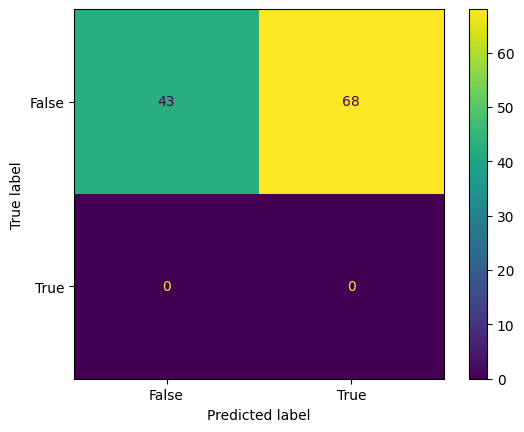

[0, 1, 2, 3, 4, 6, 7, 8, 13, 14, 15, 19, 20, 21, 22, 23, 24, 27, 28, 31, 35, 38, 39, 40, 41, 42, 43, 45, 46, 47, 49, 50, 51, 53, 55, 57, 58, 59, 60, 61, 62, 66, 67, 69, 70, 71, 73, 74, 77, 78, 79, 81, 82, 86, 87, 92, 93, 96, 97, 99, 101, 102, 103, 105, 106, 107, 109, 110]


In [9]:
txts = [Entity.clean_text(text) for i, text in enumerate(texts_F)]

y_pred = []
y_true = []
bad = []

verbose = False

i = 0
for doc in tqdm(nlp.pipe(txts, batch_size=16), total=len(txts)):
    doc_extended = Entity.ExtendedDoc(doc)

    if verbose:
        print()
        print('Text', i)
        print(doc.text)
        print()
        print()
    
    # Find Entity Instances
    find = Entity.FindEntityInstances(doc_extended)
    ent_instances = find(verbose=False)
    
    # Resolve Entity Instances
    resolve = Entity.ResolveEntityInstances(doc_extended, conn)
    ents = resolve(ent_instances, verbose=False)
    
    # Flag
    flag_ent = satisfies_ent_req(doc_extended, ent_instances, ents, verbose=False)
    flag_int = satisfies_int_req(doc_extended, ent_instances, ents, verbose=False)

    # Put Flags Together
    y_pred.append(flag_ent and flag_int)
    y_true.append(False)
    
    if y_true[-1] != y_pred[-1]:
        bad.append(i)

    i += 1

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()
print(bad)

In [ ]:
# TESTING FUNCTION CALLS
# wrappers = [a for a in gc.get_objects() if isinstance(a, functools._lru_cache_wrapper)]
# for wrapper in wrappers:
    # wrapper.cache_clear()

# profiler = cProfile.Profile()
# profiler.enable()

# text = txts[2]
# doc = nlp(text)
# doc_extended = Entity.ExtendedDoc(doc)

# # Find Entity Instances
# find = Entity.FindEntityInstances(doc_extended)
# ent_instances = find(verbose=False)

# # Resolve Entity Instances
# resolve = Entity.ResolveEntityInstances(doc_extended, conn)
# ents = resolve(ent_instances, verbose=False)

# profiler.disable()
# stats = pstats.Stats(profiler)
# stats.strip_dirs()
# stats.sort_stats("cumulative")
# stats.print_stats(10)

In [10]:
filename = "4-ScreenByEntities"


def save(*, mask, counts, errors, suffix):
    outputs = {
        "counts": counts,
        "mask": mask,
        "errors": errors
    }
    
    with open(rf'{filename}-{suffix or 0}.pickle', 'wb') as file:
        pickle.dump(outputs, file)


def load(suffix):
    outputs = {
        "errors": {},
        "counts": {
            None: 0, 
            True: 0, 
            False: 0
        },
        "mask": []
    }

    fn = f'{filename}-{suffix or 0}.pickle'

    # Nothing To Load
    if not os.path.isfile(fn):
        return outputs
    else:
        with open(fn, 'rb') as file:
            return pickle.load(file)

In [11]:
papers = pd.read_csv('3_Papers_Screened.csv')
texts = papers.Abstract.tolist()
number_texts = len(texts)

In [12]:
# type: ignore
suffix = None

outputs = load(suffix)
mask = outputs['mask']
counts = outputs['counts']
errors = outputs['errors']

i = len(mask)

progress = tqdm(nlp.pipe(texts, batch_size=128), total=number_texts)
for doc in progress:
    progress.set_postfix({
        'Errors': counts[None], 
        'Included': counts[True], 
        'Excluded': counts[False]
    }, refresh=True)

    # Auto-Save
    if (i + 1) % 256:
        save(
            mask=mask, 
            counts=counts, 
            errors=errors, 
            suffix=suffix
        )

    # Determine Flag
    try:
        doc_extended = Entity.ExtendedDoc(doc)
        
        # Find Entity Instances
        find = Entity.FindEntityInstances(doc_extended)
        ent_instances = find(verbose=False)
        
        # Resolve Entity Instances
        resolve = Entity.ResolveEntityInstances(doc_extended, conn)
        ents = resolve(ent_instances, verbose=False)
        
        # Flag
        flag_ent = satisfies_ent_req(doc_extended, ent_instances, ents, verbose=False)
        flag_int = satisfies_int_req(doc_extended, ent_instances, ents, verbose=False)
        flag = flag_ent and flag_int
    
    except Exception as e:
        flag = None
        errors[i] = e

    counts[flag] += 1
    mask.append(flag)
    
    i += 1

save(
    mask=mask, 
    counts=counts, 
    errors=errors, 
    suffix=suffix
)

100%|█████████████████████████████████████████████████████████████████████| 27783/27783 [1:11:41<00:00,  6.46it/s, Errors=0, Included=20577, Excluded=7205]
